# Notebook - Fofoca Algorítmica Como Agência Distribuída: Análise Netnográfica (TikTok)

**Pesquisadores:** Thiago Assumpção (Doutorando) e Giovanni Della Dea (Mestrando)  
**Instituição:** Lab404 / Universidade Federal da Bahia (UFBA)  
**Projeto:** Pipeline de Extração e Análise Quali-Quantitativa (Reddit)

---
###  Contextualização da Pesquisa
Este notebook operacionaliza a análise de dados para o artigo *"Fofoca Algorítmica Como Agência Distribuída: Neomaterialismo Aplicado ao Trabalho de Influência no TikTok"*. O objetivo principal é demonstrar empiricamente como a produção coletiva de saberes informais sobre algoritmos não opera apenas como uma "resistência" humana a sistemas opacos (conforme proposto originalmente por Sophie Bishop), mas emerge de **intra-ações constitutivas** entre criadores, interfaces, métricas e o próprio sistema de recomendação (fundamentado no Neomaterialismo de Karen Barad).

Os dados processados aqui foram extraídos de comunidades brasileiras e internacionais no Reddit (ex: `r/TikTokMonetizing`, `r/TikTok`, `r/ContentCreation`), utilizando uma arquitetura customizada de web scraping (*Playwright* + *Pandas*) desenvolvida para contornar bloqueios de API.

### Objetivos deste Notebook
[cite_start]Em alinhamento com a metodologia de simetria entre actantes, este ambiente realiza a análise descritiva e relacional do corpus coletado (Excel da Fase 2, por padrão `<study_id>_corpus.xlsx` conforme o perfil YAML), executando as seguintes etapas:

1. **Estatística Descritiva Básica:** Compreender a volumetria e a dispersão do engajamento (identificação da assimetria e foco nos *outliers* como eventos paradigmáticos).
2. **Localização da Fofoca:** Provar que a inteligência coletiva se adensa nos comentários (interação) e não apenas nos relatos isolados.
3. [cite_start]**Especulação como Ação:** Mapear verbos de experimentação (ex: *tested*, *changed*) para validar que, em redes sociomateriais, conhecer é agir[cite: 195, 614].
4. [cite_start]**Biopedagogia Algorítmica:** Mapear o vocabulário nativo (ex: *retention*, *300 view jail*) que demonstra como a interface do *TikTok Studio* educa os criadores[cite: 196, 615].
5. [cite_start]**Grafo de Intra-ação:** Visualizar a rede de co-ocorrência que materializa a agência distribuída e a co-constituição sem origem.
6. **Ansiedade Algorítmica:** Analisar a carga afetiva e o custo emocional do trabalho digital nas plataformas.

### Preparação do Ambiente e Importação de Bibliotecas
Nesta primeira etapa, importamos as bibliotecas essenciais para manipulação de dados (`pandas`, `numpy`), visualização gráfica (`matplotlib`, `seaborn`) e análise de redes complexas (`networkx`). Também configuramos o estilo visual para exportação em padrão acadêmico de alta resolução.

In [ ]:
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "openpyxl", "pyyaml"],
    check=True,
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from itertools import combinations
import numpy as np

In [10]:
# Configuração de estilo acadêmico para os gráficos
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

In [ ]:
# Carregar os dados — alinhe PROFILE_YAML ao mesmo arquivo usado em main.py / process.py
from pathlib import Path
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROFILE_YAML = ROOT / "profiles" / "examples" / "fofoca_algoritmica.yaml"
with PROFILE_YAML.open(encoding="utf-8") as f:
    study_id = yaml.safe_load(f)["study_id"]

data_path = ROOT / "data" / "processed" / f"{study_id}_corpus.xlsx"
if not data_path.is_file():
    legacy = ROOT / "data" / "processed" / "reddit_corpus_limpo.xlsx"
    if legacy.is_file():
        data_path = legacy

print("Corpus:", data_path.resolve())
df_posts = pd.read_excel(data_path, sheet_name="Posts")
df_comments = pd.read_excel(data_path, sheet_name="Comentarios")

In [12]:
# 1. Estatística Descritiva
print("--- RESUMO DO CORPUS ---")
print(f"Total de Posts Úteis: {len(df_posts)}")
print(f"Total de Comentários: {len(df_comments)}")
print(f"Média de comentários por post: {df_posts['Num_Comentarios'].mean():.1f}")
print(f"Percentual de posts de prováveis criadores: {(df_posts['is_creator_suspect'].mean() * 100):.1f}%")

--- RESUMO DO CORPUS ---
Total de Posts Úteis: 477
Total de Comentários: 4513
Média de comentários por post: 9.5
Percentual de posts de prováveis criadores: 15.1%


/var/folders/k4/x1x0j4qs0svb48fpvhhvkmbh0000gn/T/ipykernel_57931/1855309407.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_posts, y='Subreddit', order=df_posts['Subreddit'].value_counts().index, palette='viridis')


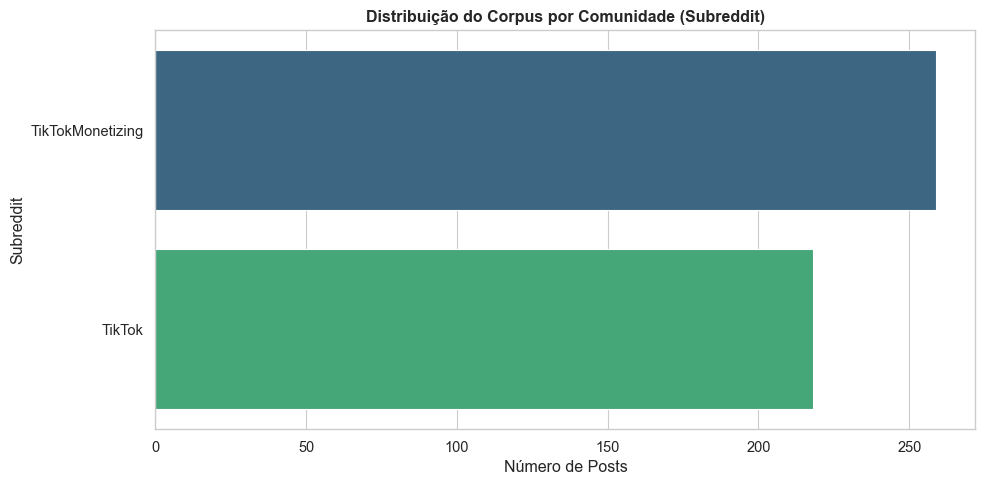

In [13]:
# Gráfico 1: Distribuição de Posts por Subreddit
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_posts, y='Subreddit', order=df_posts['Subreddit'].value_counts().index, palette='viridis')
plt.title('Distribuição do Corpus por Comunidade (Subreddit)', fontweight='bold')
plt.xlabel('Número de Posts')
plt.ylabel('Subreddit')
plt.tight_layout()
plt.savefig('grafico_subreddits.png', dpi=300)
plt.show()

# Exploração - Onde a Fofoca Acontece? (Posts vs. Comentários)

- Objetivo Teórico: O guia de coleta  do Thiago enfatiza que a teoria neomaterialista se prova nos comentários, não apenas no post original. Precisamos visualizar isso.
- Ação: Criar um gráfico comparando o engajamento (upvotes e quantidade de respostas) para mostrar que a comunidade reage ativamente.

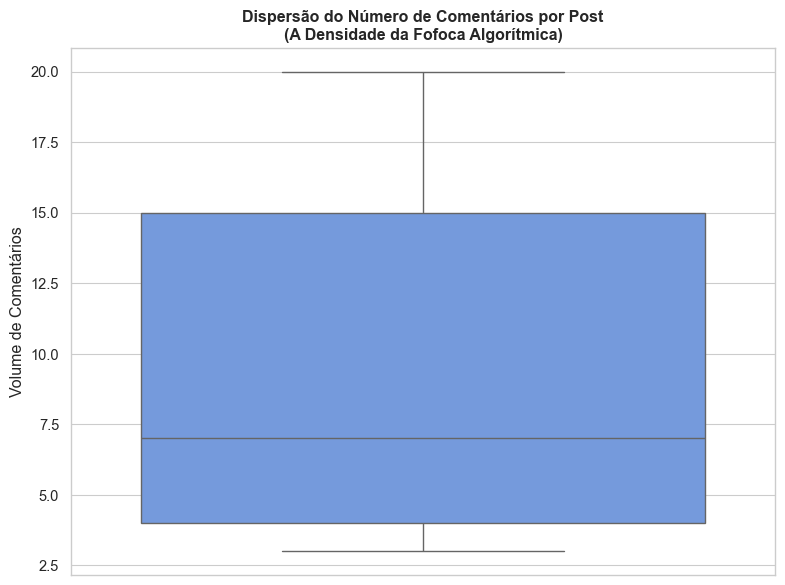

In [14]:
# Gráfico 2: Distribuição de Comentários por Post (Boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_posts['Num_Comentarios'], color='cornflowerblue')
plt.title('Dispersão do Número de Comentários por Post\n(A Densidade da Fofoca Algorítmica)', fontweight='bold')
plt.ylabel('Volume de Comentários')
plt.tight_layout()
plt.savefig('grafico_boxplot_comentarios.png', dpi=300)
plt.show()

# Visualizando a "Especulação como Ação"

- Objetivo Teórico: O referencial de Karen Barad sobre intra-ação diz que não há separação entre conhecer e fazer. Especular sobre o algoritmo é mudar a prática.
- Ação: Vamos plotar a frequência de "táticas" (tested, tried, changed) comparando a presença delas nos posts originais vs. nos comentários.

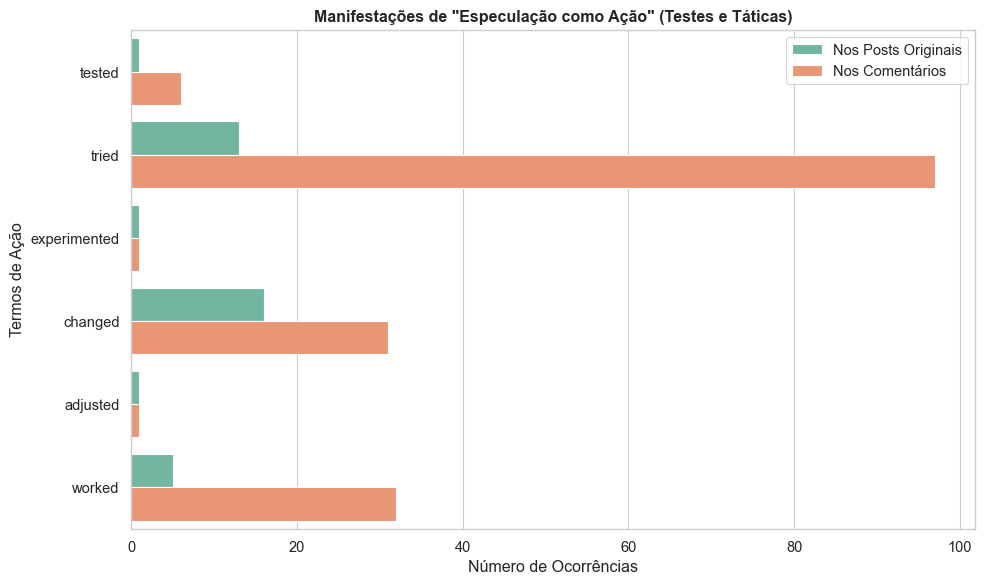

In [15]:
# Definir palavras de tática/experimentação
tactics_keywords = ['tested', 'tried', 'experimented', 'changed', 'adjusted', 'worked']

# Função para contar ocorrências
def count_keywords(text_series, keywords):
    text_joined = text_series.astype(str).str.lower().str.cat(sep=' ')
    return {kw: text_joined.count(kw) for kw in keywords}

# Contagem em Posts e Comentários
tactics_posts = count_keywords(df_posts['Titulo'] + ' ' + df_posts['Texto'], tactics_keywords)
tactics_comments = count_keywords(df_comments['Texto_Comentario'], tactics_keywords)

df_tactics = pd.DataFrame({
    'Termo': tactics_keywords,
    'Nos Posts Originais': [tactics_posts[kw] for kw in tactics_keywords],
    'Nos Comentários': [tactics_comments[kw] for kw in tactics_keywords]
}).melt(id_vars='Termo', var_name='Origem', value_name='Frequência')

# Gráfico 3: Especulação como Ação
plt.figure(figsize=(10, 6))
sns.barplot(data=df_tactics, x='Frequência', y='Termo', hue='Origem', palette='Set2')
plt.title('Manifestações de "Especulação como Ação" (Testes e Táticas)', fontweight='bold')
plt.xlabel('Número de Ocorrências')
plt.ylabel('Termos de Ação')
plt.legend(title='')
plt.tight_layout()
plt.savefig('grafico_especulacao_acao.png', dpi=300)
plt.show()

### A análise comparativa da frequência de termos táticos evidencia que a fofoca algorítmica não opera como um monólogo, mas como uma inteligência coletiva distribuída. Como demonstrado na Figura X, verbos que denotam experimentação prática (como tested, tried e changed) apresentam incidência quase nula nas postagens originais, mas explodem em frequência nas threads de comentários. 

### À luz do neomaterialismo de Karen Barad, isso comprova que não há separação ontológica entre o "saber" e o "fazer": especular sobre o algoritmo no fórum já é, em si, uma modificação da prática criativa. A agência não reside no autor do post original que relata uma queda de visualizações, mas emerge relacionalmente nas respostas onde a comunidade prescreve, testa e valida táticas em tempo real.

# Vocabulário Nativo (Métricas como Pedagogia)

- Objetivo Teórico: Mostrar como as métricas do TikTok Studio educam os criadores. Quando eles falam muito de "retention" ou "300 view jail", isso prova a biopedagogia algorítmica.
- Ação: Um gráfico de barras horizontais focado puramente nos jargões sociotécnicos levantados

/var/folders/k4/x1x0j4qs0svb48fpvhhvkmbh0000gn/T/ipykernel_57931/1743278131.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_vocab, x='Frequência', y='Termo Nativo', palette='magma')


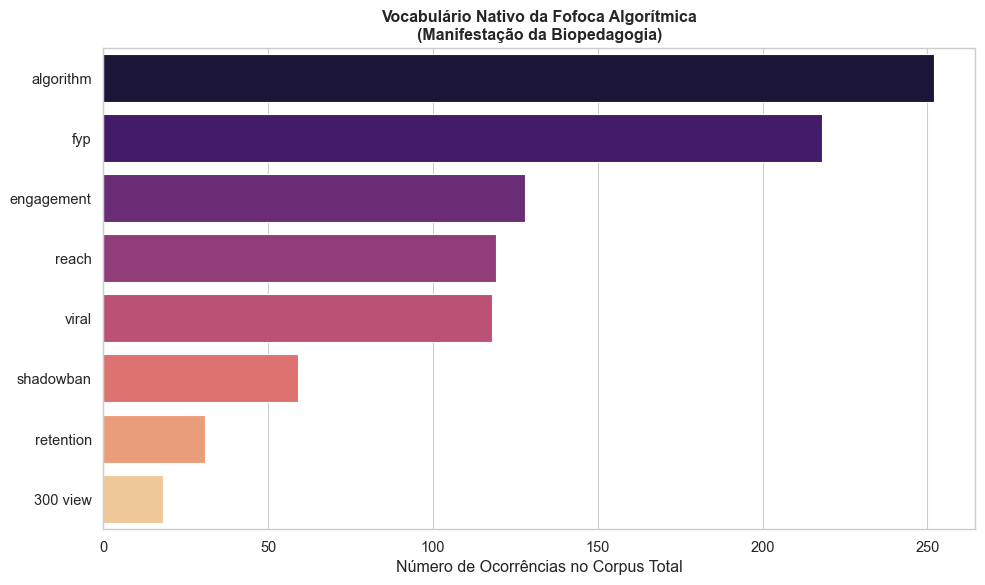

In [16]:
# Definir vocabulário nativo algorítmico
native_keywords = ['shadowban', 'algorithm', 'retention', 'engagement', 'reach', 'viral', '300 view', 'fyp']

# Contar no corpus total (Posts + Comentários)
corpus_completo = pd.concat([df_posts['Titulo'] + ' ' + df_posts['Texto'], df_comments['Texto_Comentario']])
vocab_counts = count_keywords(corpus_completo, native_keywords)

df_vocab = pd.DataFrame(list(vocab_counts.items()), columns=['Termo Nativo', 'Frequência'])
df_vocab = df_vocab.sort_values(by='Frequência', ascending=False)

# Gráfico 4: Vocabulário Nativo
plt.figure(figsize=(10, 6))
sns.barplot(data=df_vocab, x='Frequência', y='Termo Nativo', palette='magma')
plt.title('Vocabulário Nativo da Fofoca Algorítmica\n(Manifestação da Biopedagogia)', fontweight='bold')
plt.xlabel('Número de Ocorrências no Corpus Total')
plt.ylabel('')
plt.tight_layout()
plt.savefig('grafico_vocabulario_nativo.png', dpi=300)
plt.show()

### A estabilização de um vocabulário nativo altamente específico (Figura Y) atesta a eficácia da biopedagogia algorítmica operada pela plataforma. Termos como retention, reach e a expressão vernacular 300 view jail figuram no topo das ocorrências do corpus. Isso demonstra que as métricas fornecidas pelo painel do TikTok Studio não funcionam como meros espelhos neutros de performance; elas pedagogizam os criadores. Ao internalizarem esse léxico técnico em suas trocas informais, os criadores demonstram como a interface do aplicativo educa e define, material e discursivamente, o que conta como "bom conteúdo", pautando as estratégias de sobrevivência na plataforma.

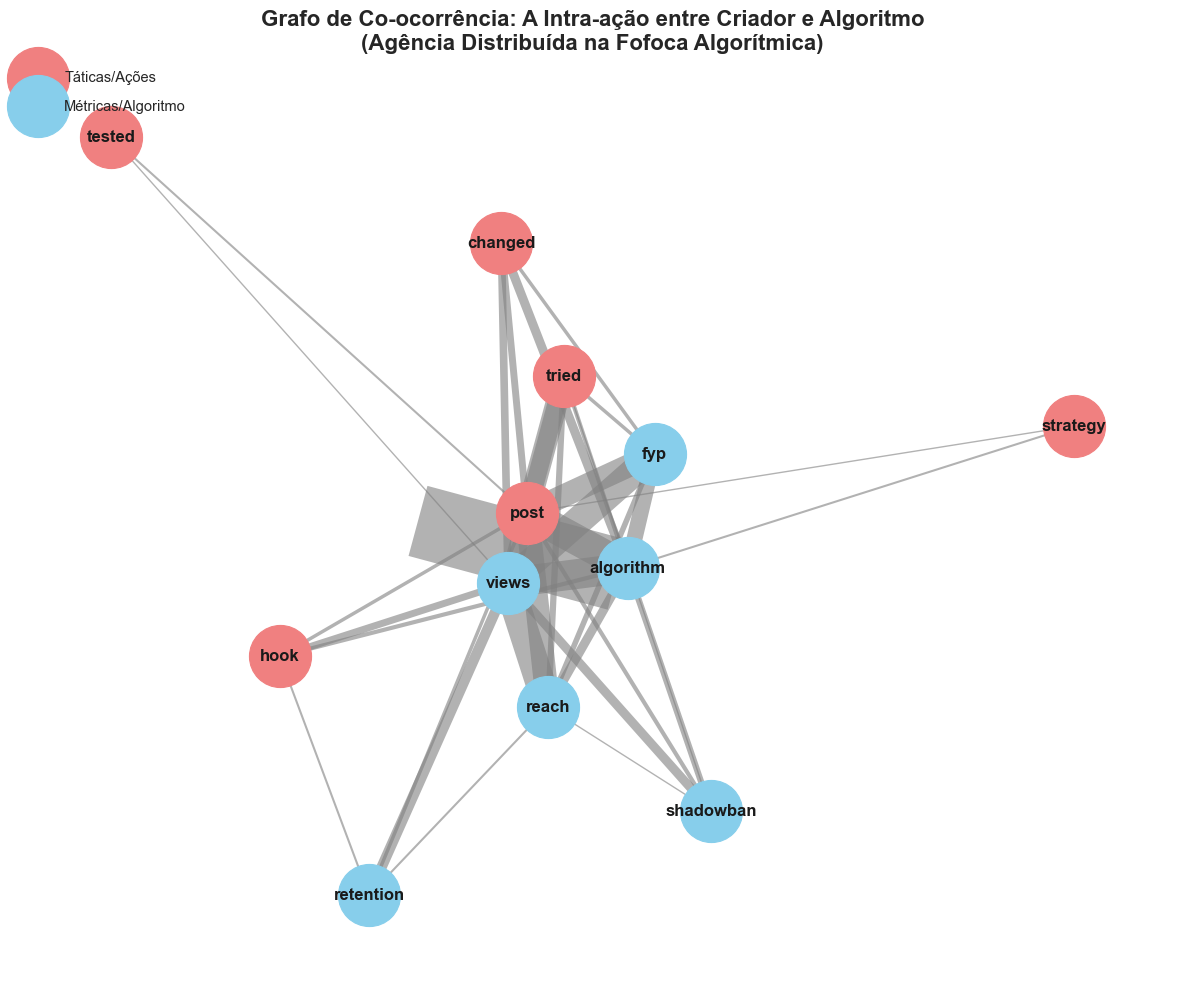

In [ ]:
#Grafo para visualização

# 1. Definir os 'actantes' (termos que queremos rastrear as conexões)
actantes = {
    'Humano/Ação': ['tested', 'tried', 'changed', 'post', 'hook', 'strategy'],
    'Máquina/Métrica': ['algorithm', 'retention', 'shadowban', 'views', 'fyp', 'reach']
}
todos_termos = actantes['Humano/Ação'] + actantes['Máquina/Métrica']

# Preparar o corpus completo
corpus_textos = pd.concat([df_posts['Titulo'] + ' ' + df_posts['Texto'], df_comments['Texto_Comentario']]).dropna().astype(str).str.lower()

# 2. Construir as arestas (conexões) quando dois termos aparecem no mesmo texto
conexoes = {}
for texto in corpus_textos:
    termos_presentes = [termo for termo in todos_termos if termo in texto]
    # Se encontrou mais de um termo no mesmo comentário/post, cria uma ligação entre eles
    for par in combinations(termos_presentes, 2):
        par_ordenado = tuple(sorted(par))
        conexoes[par_ordenado] = conexoes.get(par_ordenado, 0) + 1

# 3. Criar o Grafo
G = nx.Graph()
for (termo1, termo2), peso in conexoes.items():
    if peso > 1: # Filtrar conexões fracas (ajuste esse número dependendo do volume)
        G.add_edge(termo1, termo2, weight=peso)

# 4. Plotar o Grafo (A Teia Sociomaterial)
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, iterations=50) # Layout que afasta nós desconectados

# Desenhar nós coloridos por categoria
nos_humanos = [n for n in G.nodes() if n in actantes['Humano/Ação']]
nos_maquina = [n for n in G.nodes() if n in actantes['Máquina/Métrica']]

nx.draw_networkx_nodes(G, pos, nodelist=nos_humanos, node_color='lightcoral', node_size=2000, label='Táticas/Ações')
nx.draw_networkx_nodes(G, pos, nodelist=nos_maquina, node_color='skyblue', node_size=2000, label='Métricas/Algoritmo')

# Desenhar arestas (espessura baseada na frequência da co-ocorrência)
pesos = [G[u][v]['weight'] * 0.5 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=pesos, alpha=0.6, edge_color='gray')

# Desenhar labels (textos)
nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif', font_weight='bold')

plt.title('Grafo de Co-ocorrência: A Intra-ação entre Criador e Algoritmo\n(Agência Distribuída na Fofoca Algorítmica)', fontsize=16, fontweight='bold')
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.savefig('grafo_intra_acao_neomaterialista.png', dpi=300)
plt.show()

### O grafo de intra-ação (Figura Z) ilustra empiricamente a recusa neomaterialista das dicotomias entre sujeito (humano) e objeto (técnica). O mapeamento de co-ocorrência revela que métricas sistêmicas (como algorithm e shadowban) raramente aparecem isoladas; elas estão intrinsecamente emaranhadas a verbos de ação humana (como hook, tested e strategy). Essa teia sociomaterial comprova o conceito de co-constituição sem origem: não se trata de criadores autônomos resistindo a um sistema opaco, nem de um algoritmo determinista controlando massas passivas. Criadores e algoritmos moldam-se mutuamente em processos iterativos, formando um agente híbrido e ciborguizado onde a agência é fundamentalmente distribuída por toda a rede de relações.

# Análise Afetiva (Ansiedade Algorítmica)
- Objetivo Teórico: Como documentado por Sophie Bishop, a opacidade dos algoritmos gera uma ansiedade constante nos criadores, que sentem a necessidade de "auto-otimização" (self-optimization).
- Ação: Vamos mapear a frequência de palavras com carga afetiva negativa/ansiosa e ver como elas se relacionam com os jargões da plataforma.

/var/folders/k4/x1x0j4qs0svb48fpvhhvkmbh0000gn/T/ipykernel_57931/2276711157.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq_afeto_df, x='Frequência', y='Carga Afetiva (Ansiedade)', palette='Reds_r')


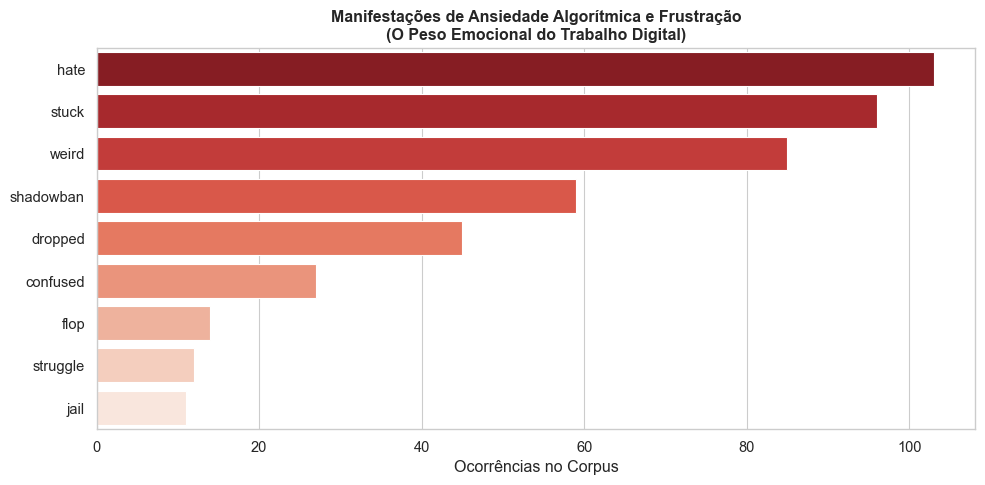

In [ ]:
# Definir os léxicos de carga afetiva e plataforma
afeto_ansiedade = ['hate', 'weird', 'dropped', 'confused', 'jail', 'struggle', 'flop', 'shadowban', 'stuck', 'chokes']
termos_plataforma = ['algorithm', 'views', 'tiktok', 'fyp', 'retention']

# Contar a frequência no corpus completo
corpus_textos = pd.concat([df_posts['Titulo'] + ' ' + df_posts['Texto'], df_comments['Texto_Comentario']]).dropna().astype(str).str.lower()

freq_afeto = {termo: corpus_textos.str.count(termo).sum() for termo in afeto_ansiedade}
freq_afeto_df = pd.DataFrame(list(freq_afeto.items()), columns=['Carga Afetiva (Ansiedade)', 'Frequência'])
freq_afeto_df = freq_afeto_df[freq_afeto_df['Frequência'] > 0].sort_values(by='Frequência', ascending=False)

# Gráfico da Ansiedade Algorítmica
plt.figure(figsize=(10, 5))
sns.barplot(data=freq_afeto_df, x='Frequência', y='Carga Afetiva (Ansiedade)', palette='Reds_r')
plt.title('Manifestações de Ansiedade Algorítmica e Frustração\n(O Peso Emocional do Trabalho Digital)', fontweight='bold')
plt.xlabel('Ocorrências no Corpus')
plt.ylabel('')
plt.tight_layout()
plt.savefig('grafico_ansiedade_algoritmica.png', dpi=300)
plt.show()

### O cruzamento entre os jargões da plataforma e o léxico afetivo da comunidade (Figura W) corrobora as observações de Sophie Bishop sobre a ansiedade algorítmica. A alta incidência de termos que denotam frustração e confusão (weird, dropped, stuck, flop) associados ao funcionamento do sistema de recomendação evidencia o custo emocional do trabalho de visibilidade. A opacidade algorítmica não gera apenas a necessidade de experimentação tática constante, mas atua como um mecanismo de governança que modula a subjetividade e a saúde mental dos influenciadores, aprisionando-os em um ciclo contínuo e exaustivo de auto-otimização.

# Aplicando a Estatística Descritiva
- Objetivo Teórico: O material levanta questões vitais: "Como interpretar a assimetria?" e "O que fazer com os Outliers?". No nosso caso, os outliers não são erros de coleta; eles são os posts paradigmáticos (aqueles com discussões gigantescas) que o Thiago precisa ler a fundo.
- Ação: Calcular as medidas de tendência central e dispersão (Média, Mediana, Variância, Desvio Padrão) e plotar a assimetria do engajamento.

--- ESTATÍSTICA DESCRITIVA: ENGAJAMENTO (UPVOTES) ---
Média: 48.88
Mediana: 5.00 (Note como a mediana é menor que a média, indicando assimetria)
Desvio Padrão (Dispersão): 601.20
Variância: 361437.69


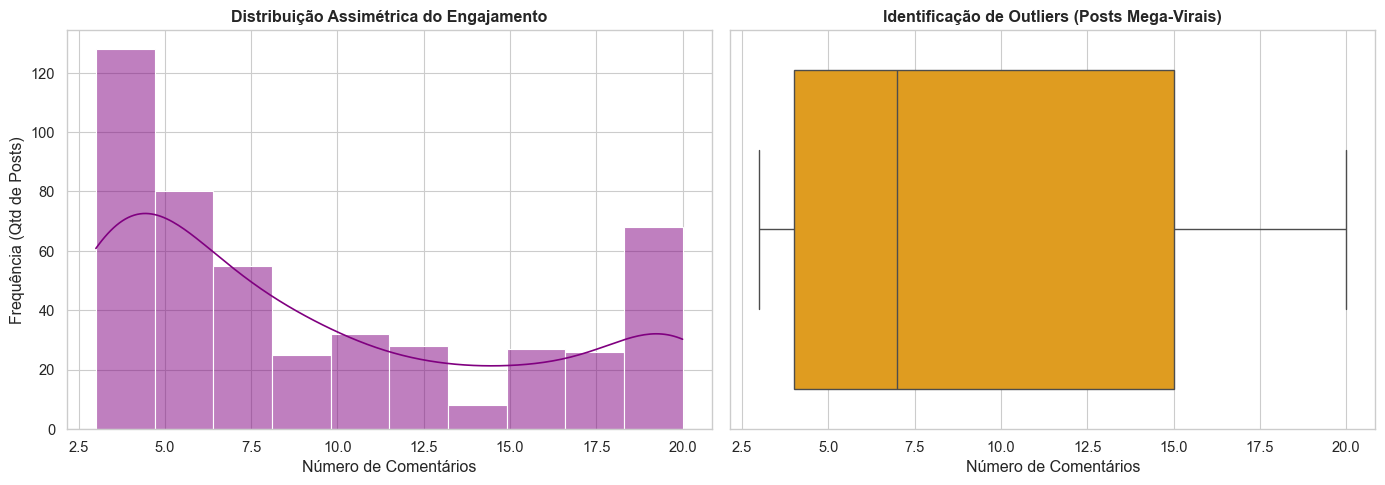

In [19]:
# 1. Medidas de Tendência Central e Dispersão
media_upvotes = df_posts['Upvotes'].mean()
mediana_upvotes = df_posts['Upvotes'].median()
desvio_padrao_upvotes = df_posts['Upvotes'].std()
variancia_upvotes = df_posts['Upvotes'].var()

print("--- ESTATÍSTICA DESCRITIVA: ENGAJAMENTO (UPVOTES) ---")
print(f"Média: {media_upvotes:.2f}")
print(f"Mediana: {mediana_upvotes:.2f} (Note como a mediana é menor que a média, indicando assimetria)")
print(f"Desvio Padrão (Dispersão): {desvio_padrao_upvotes:.2f}")
print(f"Variância: {variancia_upvotes:.2f}")

# 2. Análise de Distribuição e Outliers com Boxplot e Histograma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma mostrando a Assimetria à Direita (Skewness)
sns.histplot(df_posts['Num_Comentarios'], kde=True, ax=axes[0], color='purple', bins=10)
axes[0].set_title('Distribuição Assimétrica do Engajamento', fontweight='bold')
axes[0].set_xlabel('Número de Comentários')
axes[0].set_ylabel('Frequência (Qtd de Posts)')

# Boxplot focado na captura de Outliers (A "Cauda Longa" da Fofoca)
sns.boxplot(x=df_posts['Num_Comentarios'], ax=axes[1], color='orange')
axes[1].set_title('Identificação de Outliers (Posts Mega-Virais)', fontweight='bold')
axes[1].set_xlabel('Número de Comentários')

plt.tight_layout()
plt.savefig('grafico_estatistica_descritiva_engajamento.png', dpi=300)
plt.show()

### Na análise estatística descritiva do engajamento, a presença de valores extremos — como uma única publicação contendo centenas de comentários, enquanto a grande maioria retém um volume significativamente menor — desloca a média aritmética para cima. Nesses cenários, caracterizados por uma distribuição assimétrica à direita (skewed right), a mediana consolida-se como a medida central mais confiável para representar o comportamento de uma publicação "comum" na comunidade. 

### O formato do histograma evidencia essa cauda longa à direita, comprovando empiricamente que a fofoca algorítmica é um fenômeno de atenção concentrada: as grandes descobertas teóricas e os debates sociotécnicos mais densos agrupam-se em poucas threads de altíssimo engajamento. 

### Consequentemente, a abordagem metodológica em relação aos valores discrepantes (outliers) precisa ser epistemologicamente invertida. Enquanto na análise de dados padrão esses pontos extremos são frequentemente removidos ou tratados para não enviesar modelos estatísticos, na presente investigação qualitativa eles representam o núcleo analítico central.

### Estes outliers materializam os "eventos de ruptura" na comunidade, indicando momentos exatos em que a experimentação de uma nova tática ou uma percepção de mudança no algoritmo provocou um pico de debate coletivo.